# Segmentación de clientes con K-Means

En este cuaderno vamos a aplicar K-Means a un dataset real de segmentación de clientes.

En los cuadernos anteriores trabajamos dos situaciones distintas:

- primero, usamos datos sintéticos para ver a K-Means funcionando en condiciones ideales;
- luego, usamos el dataset Palmer Penguins para observar que K-Means puede funcionar solo parcialmente cuando los datos reales no tienen grupos tan claros.

Ahora vamos a trabajar con un caso más cercano a una aplicación práctica: la segmentación de clientes.

El objetivo será agrupar clientes de un centro comercial a partir de algunas características disponibles. En particular, nos concentraremos en dos variables:

- `Annual Income (k$)`: ingreso anual estimado del cliente, expresado en miles de dólares;
- `Spending Score (1-100)`: puntaje de gasto asignado al cliente.

La pregunta que guiará el análisis será:

> ¿Podemos encontrar perfiles de clientes a partir de su ingreso anual y su puntaje de gasto?

A lo largo del cuaderno vamos a:

- cargar y explorar el dataset;
- seleccionar variables adecuadas para clustering;
- escalar los datos;
- probar distintos valores de `k`;
- evaluar los resultados con inercia y silhouette score;
- entrenar un modelo K-Means final;
- visualizar los clusters;
- interpretar los perfiles de clientes encontrados.

La idea principal será pasar de un resultado matemático a una interpretación útil: no solo queremos saber qué cluster asignó el algoritmo, sino también qué representa cada grupo.

## 1. Importamos las librerías necesarias

Antes de comenzar, importamos las librerías que vamos a utilizar durante el cuaderno.

Usaremos `pandas` y `numpy` para trabajar con datos, `matplotlib` y `seaborn` para construir gráficos, y herramientas de `scikit-learn` para escalar variables, aplicar K-Means y evaluar el clustering.

Como en los cuadernos anteriores de esta unidad, no usaremos `Pipeline` todavía. El objetivo es que cada paso del proceso sea visible y fácil de interpretar.

In [1]:
# ---------------------------------------------------------
# Librerías para manejo de datos
# ---------------------------------------------------------
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Librerías para visualización
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Herramientas de Scikit-learn
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# ---------------------------------------------------------
# Configuración general de visualización
# ---------------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Cargamos el dataset

Vamos a cargar el dataset de clientes de un centro comercial.

Cada fila representa un cliente y cada columna contiene alguna característica asociada a esa persona.

Las columnas principales son:

- `CustomerID`: identificador del cliente.
- `Gender`: género registrado.
- `Age`: edad.
- `Annual Income (k$)`: ingreso anual estimado, expresado en miles de dólares.
- `Spending Score (1-100)`: puntaje de gasto asignado al cliente.

En este cuaderno no tenemos una variable objetivo. No vamos a predecir una etiqueta conocida, sino a buscar grupos de clientes con comportamientos similares.

Más adelante nos concentraremos especialmente en `Annual Income (k$)` y `Spending Score (1-100)`, porque esas dos variables permiten construir una segmentación visual e interpretable.

In [2]:
# ---------------------------------------------------------
# Carga del dataset desde una URL pública
# ---------------------------------------------------------

url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv"

df = pd.read_csv(url)

# ---------------------------------------------------------
# Mostramos las primeras filas
# ---------------------------------------------------------

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Revisamos la estructura general del dataset

Antes de aplicar K-Means, necesitamos conocer mejor el dataset.

Vamos a revisar:

- cuántas filas y columnas tiene;
- qué tipo de dato contiene cada columna;
- si existen valores faltantes;
- algunas estadísticas descriptivas de las variables numéricas.

Esta revisión inicial nos ayuda a decidir qué variables usar para el clustering y si hace falta realizar alguna limpieza previa.

In [3]:
# ---------------------------------------------------------
# Dimensiones generales del dataset
# ---------------------------------------------------------

print("Cantidad de filas y columnas:")
print(df.shape)

print("\nInformación general del dataset:")
df.info()

print("\nCantidad de valores faltantes por columna:")
display(df.isna().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())

Cantidad de filas y columnas:
(200, 5)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Cantidad de valores faltantes por columna:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Estadísticas descriptivas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 4. Primera lectura de las variables numéricas

El dataset contiene tres variables numéricas que podrían aportar información sobre los clientes:

- `Age`: edad.
- `Annual Income (k$)`: ingreso anual estimado, expresado en miles de dólares.
- `Spending Score (1-100)`: puntaje de gasto asignado al cliente.

También aparece `CustomerID`, pero esta columna es solamente un identificador. No representa una característica del cliente, por lo que no la usaremos para el clustering.

En esta primera etapa nos concentraremos especialmente en `Annual Income (k$)` y `Spending Score (1-100)`, porque permiten construir una segmentación visual e interpretable: clientes con distintos niveles de ingreso y distintos comportamientos de gasto.

Antes de entrenar K-Means, observaremos la distribución de estas variables.

,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


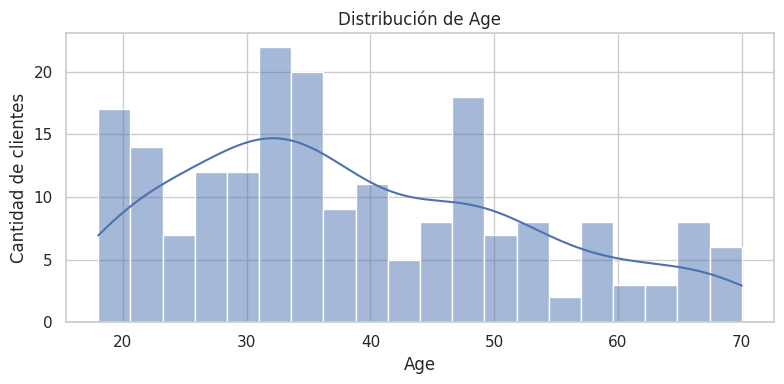

/n


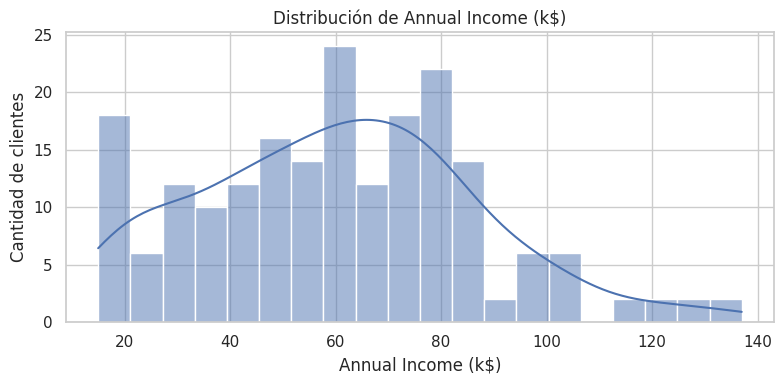

/n


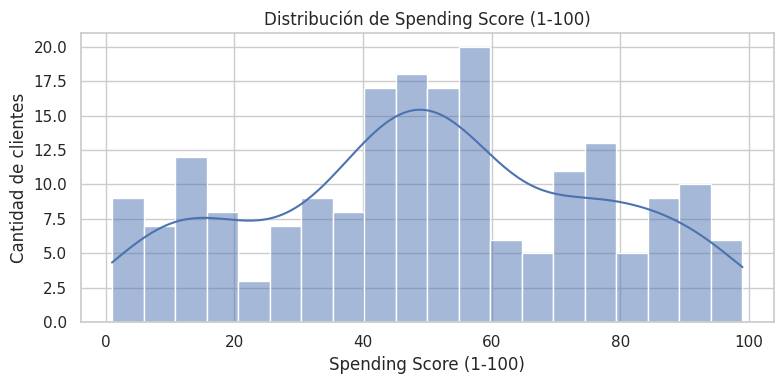

/n


In [5]:
# ---------------------------------------------------------
# Variables numéricas relevantes para explorar
# ---------------------------------------------------------

variables_exploracion = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

# ---------------------------------------------------------
# Tabla descriptiva
# ---------------------------------------------------------

resumen_variables = df[variables_exploracion].describe().T

display(resumen_variables)

# ---------------------------------------------------------
# Histogramas de las variables numéricas
# ---------------------------------------------------------

for columna in variables_exploracion:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=columna,
        bins=20,
        kde=True
    )

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Cantidad de clientes")
    plt.tight_layout()
    plt.show()

    print("/n")

## 5. Observamos la relación entre ingreso anual y puntaje de gasto

Para aplicar K-Means, vamos a comenzar con dos variables:

- `Annual Income (k$)`
- `Spending Score (1-100)`

Estas variables permiten construir una segmentación bastante interpretable.

Por ejemplo, podríamos encontrar clientes con:

- bajo ingreso y bajo puntaje de gasto;
- bajo ingreso y alto puntaje de gasto;
- ingreso medio y gasto medio;
- alto ingreso y bajo puntaje de gasto;
- alto ingreso y alto puntaje de gasto.

Antes de entrenar el modelo, vamos a graficar estas dos variables para observar si aparecen patrones visuales.

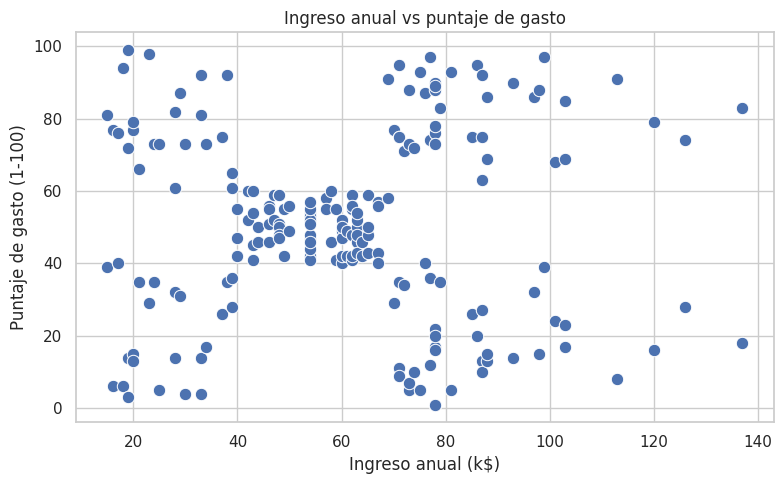

In [6]:
# ---------------------------------------------------------
# Gráfico de dispersión: ingreso anual vs puntaje de gasto
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=80
)

plt.title("Ingreso anual vs puntaje de gasto")
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Puntaje de gasto (1-100)")
plt.tight_layout()
plt.show()

## 6. Seleccionamos las variables para el clustering

A partir del gráfico anterior, vamos a construir nuestro modelo de clustering usando dos variables:

- `Annual Income (k$)`: ingreso anual del cliente.
- `Spending Score (1-100)`: puntaje de gasto.

Esta selección tiene una ventaja importante: permite interpretar los clusters de manera visual y práctica.

No usaremos `CustomerID`, porque es solo un identificador. Tampoco usaremos por ahora `Gender` ni `Age`, para mantener el análisis centrado en una segmentación clara basada en ingreso y comportamiento de gasto.

Más adelante, una vez formados los clusters, podríamos analizar si la edad o el género ayudan a describir mejor cada perfil, pero no serán variables usadas para entrenar este primer modelo.

In [7]:
# ---------------------------------------------------------
# Variables seleccionadas para clustering
# ---------------------------------------------------------

variables_clustering = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[variables_clustering]

# ---------------------------------------------------------
# Revisamos las primeras filas
# ---------------------------------------------------------

display(X.head())

print("Dimensiones de X:")
print(X.shape)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Dimensiones de X:
(200, 2)


## 7. Revisamos las escalas de las variables seleccionadas

K-Means calcula distancias entre puntos. Por eso, antes de entrenar el modelo necesitamos revisar las escalas de las variables.

En este caso, las dos variables tienen rangos distintos:

- el ingreso anual se expresa en miles de dólares;
- el puntaje de gasto va de 1 a 100.

Aunque las escalas no son extremadamente diferentes, vamos a aplicar estandarización para mantener una práctica consistente.

Antes de escalar, observemos una tabla descriptiva y un gráfico de caja de las variables seleccionadas.

,count,mean,std,min,25%,50%,75%,max
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


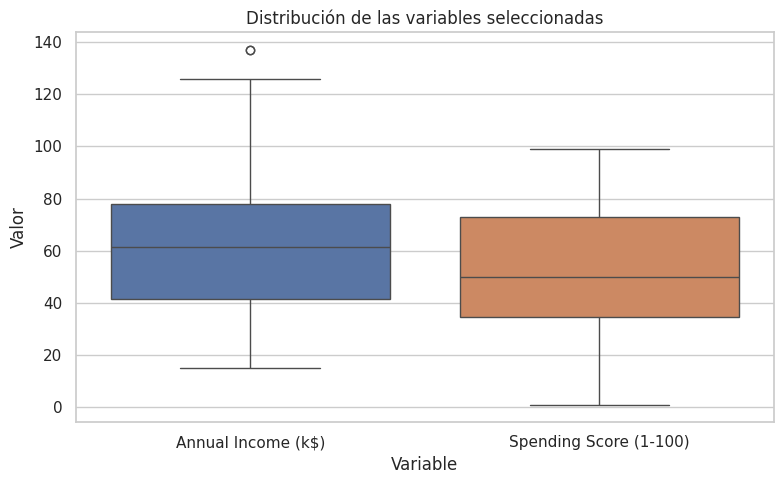

In [8]:
# ---------------------------------------------------------
# Estadísticas descriptivas de las variables seleccionadas
# ---------------------------------------------------------

resumen_clustering = X.describe().T

display(resumen_clustering)

# ---------------------------------------------------------
# Gráfico de caja para comparar escalas
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(data=X)

plt.title("Distribución de las variables seleccionadas")
plt.xlabel("Variable")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

## 8. Estandarizamos las variables

Antes de aplicar K-Means, vamos a estandarizar las variables seleccionadas.

La estandarización transforma los datos para que cada variable tenga aproximadamente:

- media igual a 0;
- desvío estándar igual a 1.

Esto es importante porque K-Means calcula distancias entre puntos. Si una variable tiene una escala más grande, podría influir más en la formación de los clusters.

Aunque en este dataset las escalas no son extremadamente diferentes, aplicar estandarización es una práctica recomendable cuando usamos algoritmos basados en distancias.

In [9]:
# ---------------------------------------------------------
# Creamos el escalador
# ---------------------------------------------------------

escalador = StandardScaler()

# ---------------------------------------------------------
# Ajustamos el escalador y transformamos los datos
# ---------------------------------------------------------

X_escalado = escalador.fit_transform(X)

# ---------------------------------------------------------
# Convertimos el resultado a DataFrame para visualizarlo mejor
# ---------------------------------------------------------

X_escalado_df = pd.DataFrame(
    X_escalado,
    columns=variables_clustering
)

# ---------------------------------------------------------
# Mostramos las primeras filas escaladas
# ---------------------------------------------------------

display(X_escalado_df.head())

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## 9. Verificamos el resultado de la estandarización

Después de escalar los datos, vamos a revisar nuevamente sus estadísticas descriptivas.

Si la estandarización se aplicó correctamente, las variables deberían tener media cercana a 0 y desvío estándar cercano a 1.

También construiremos un gráfico de caja para comprobar visualmente que las dos variables quedaron en una escala comparable.

,count,mean,std,min,25%,50%,75%,max
Annual Income (k$),200.0,-2.131628e-16,1.002509,-1.738999,-0.727509,0.035879,0.665675,2.917671
Spending Score (1-100),200.0,-1.465494e-16,1.002509,-1.910021,-0.599793,-0.007764,0.885132,1.894492


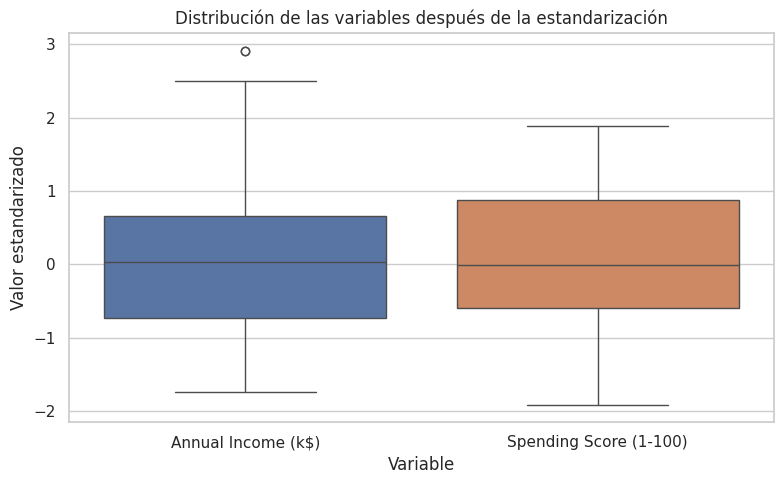

In [10]:
# ---------------------------------------------------------
# Estadísticas descriptivas de los datos escalados
# ---------------------------------------------------------

resumen_escalado = X_escalado_df.describe().T

display(resumen_escalado)

# ---------------------------------------------------------
# Gráfico de caja de las variables escaladas
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(data=X_escalado_df)

plt.title("Distribución de las variables después de la estandarización")
plt.xlabel("Variable")
plt.ylabel("Valor estandarizado")
plt.tight_layout()
plt.show()

## 10. Buscamos una cantidad razonable de clusters

Ahora vamos a probar distintos valores de `k`.

En un problema real de clustering no sabemos de antemano cuántos grupos existen. Por eso, no conviene elegir `k` de manera arbitraria sin revisar el comportamiento del modelo.

Vamos a entrenar varios modelos K-Means, usando valores de `k` entre 2 y 10.

Para cada valor vamos a calcular:

- **inercia**: mide qué tan compactos son los clusters;
- **silhouette score**: mide qué tan bien separados están los clusters.

La inercia suele disminuir cuando aumenta `k`, por lo que no debe usarse sola. El silhouette score aporta una mirada complementaria sobre la calidad de la separación.

In [11]:
# ---------------------------------------------------------
# Probamos distintos valores de k
# ---------------------------------------------------------

valores_k = range(2, 11)

resultados_k = []

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_escalado_df)

    etiquetas = modelo.labels_

    inercia = modelo.inertia_
    silueta = silhouette_score(X_escalado_df, etiquetas)

    resultados_k.append({
        "k": k,
        "inercia": inercia,
        "silhouette_score": silueta
    })

# ---------------------------------------------------------
# Convertimos los resultados en un DataFrame
# ---------------------------------------------------------

resultados_k_df = pd.DataFrame(resultados_k)

display(resultados_k_df)

,k,inercia,silhouette_score
0,2,269.691012,0.321271
1,3,157.704008,0.466585
2,4,108.921317,0.493907
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
6,8,37.228188,0.455215
7,9,32.392268,0.457085
8,10,29.981898,0.443171


## 11. Visualizamos la inercia y el silhouette score

La tabla anterior nos permite comparar distintos valores de `k`, pero los gráficos ayudan a interpretar mejor la tendencia.

Vamos a construir dos visualizaciones:

1. Un gráfico de **inercia**, para aplicar el método del codo.
2. Un gráfico de **silhouette score**, para comparar la separación de los clusters.

En este caso, buscamos un valor de `k` que produzca clusters compactos, bien separados y que además tenga sentido para interpretar perfiles de clientes.

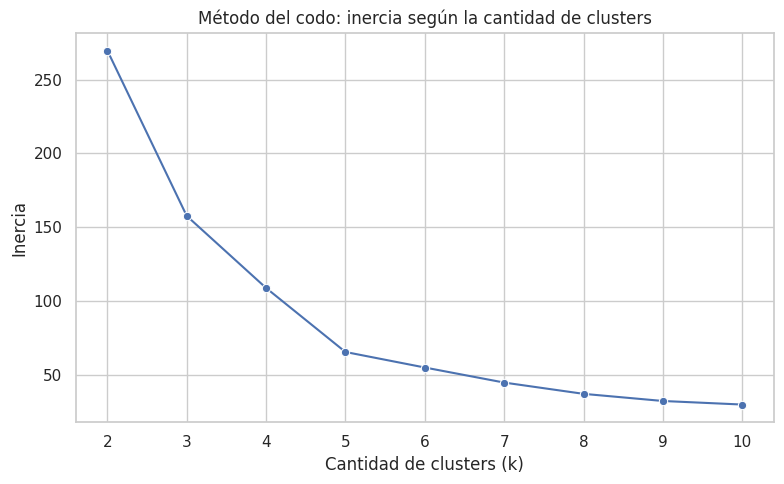

/n


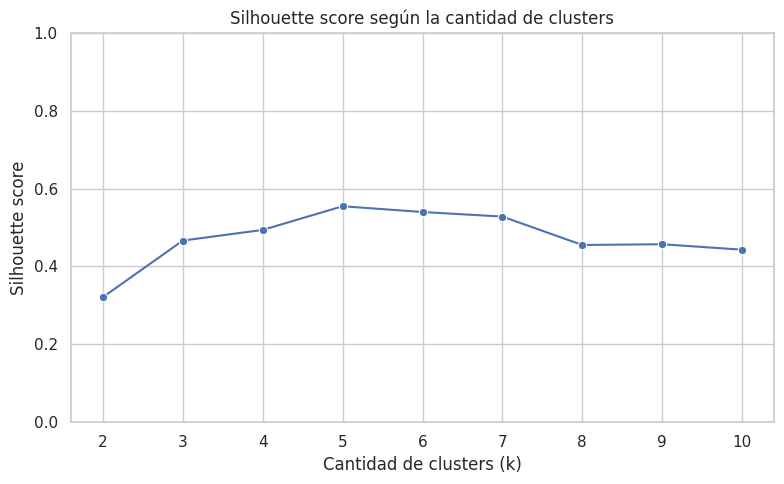

In [13]:
# ---------------------------------------------------------
# Gráfico del método del codo usando la inercia
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=resultados_k_df,
    x="k",
    y="inercia",
    marker="o"
)

plt.title("Método del codo: inercia según la cantidad de clusters")
plt.xlabel("Cantidad de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(resultados_k_df["k"])
plt.tight_layout()
plt.show()

print("/n")

# ---------------------------------------------------------
# Gráfico del silhouette score
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=resultados_k_df,
    x="k",
    y="silhouette_score",
    marker="o"
)

plt.title("Silhouette score según la cantidad de clusters")
plt.xlabel("Cantidad de clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(resultados_k_df["k"])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 12. Elegimos un valor de k

A partir de los resultados anteriores, `k = 5` aparece como una elección razonable.

En el gráfico de inercia, la mejora es importante hasta llegar a 5 clusters. Después de ese punto, la inercia sigue bajando, pero con ganancias menores.

Además, el silhouette score alcanza su valor más alto justamente en `k = 5`. Esto indica que, entre los valores probados, esa cantidad de clusters logra una buena combinación entre compacidad y separación.

Por eso, vamos a entrenar el modelo final usando:

`k = 5`

Esta elección también es útil desde el punto de vista interpretativo, porque permite describir perfiles de clientes diferenciados según ingreso anual y puntaje de gasto.

## 13. Entrenamos el modelo final con k = 5

A partir del análisis anterior, vamos a entrenar el modelo final usando `k = 5`.

Esto significa que K-Means buscará dividir los clientes en cinco grupos, según su ingreso anual y su puntaje de gasto.

Luego agregaremos la etiqueta de cluster al dataset original para poder analizar e interpretar cada segmento.

In [14]:
# ---------------------------------------------------------
# Creamos el modelo final K-Means con k = 5
# ---------------------------------------------------------

kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# ---------------------------------------------------------
# Entrenamos el modelo con los datos escalados
# ---------------------------------------------------------

kmeans_final.fit(X_escalado_df)

# ---------------------------------------------------------
# Obtenemos las etiquetas de cluster asignadas
# ---------------------------------------------------------

clusters = kmeans_final.labels_

print("Modelo K-Means final entrenado correctamente.")
print("Primeras etiquetas de cluster asignadas:")
print(clusters[:20])

Modelo K-Means final entrenado correctamente.
Primeras etiquetas de cluster asignadas:
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2]


## 14. Agregamos los clusters al dataset

El modelo ya asignó un cluster a cada cliente.

Estas etiquetas aparecen como números: `0`, `1`, `2`, `3` y `4`.

Como vimos en los cuadernos anteriores, estos números no tienen un significado propio. El cluster `0` no es mejor ni peor que el cluster `1`; simplemente es una etiqueta interna generada por el algoritmo.

Ahora vamos a agregar esa información al dataset original para poder analizar cuántos clientes quedaron en cada grupo y qué características tiene cada segmento.

In [15]:
# ---------------------------------------------------------
# Creamos una copia del dataset original
# ---------------------------------------------------------

df_clusters = df.copy()

# ---------------------------------------------------------
# Agregamos la etiqueta de cluster asignada por K-Means
# ---------------------------------------------------------

df_clusters["cluster"] = clusters

# ---------------------------------------------------------
# Mostramos las primeras filas
# ---------------------------------------------------------

display(df_clusters.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 15. Analizamos cuántos clientes quedaron en cada cluster

Una primera forma de interpretar el resultado es contar cuántos clientes quedaron asignados a cada cluster.

Esto nos permite observar si el algoritmo formó grupos de tamaño similar o si algunos segmentos son más pequeños que otros.

En segmentación de clientes, el tamaño de cada grupo también puede ser útil para tomar decisiones. Por ejemplo, un segmento pequeño pero de alto interés comercial podría requerir una estrategia distinta a un segmento más grande y general.

,count
cluster,
0,81
1,39
2,22
3,35
4,23


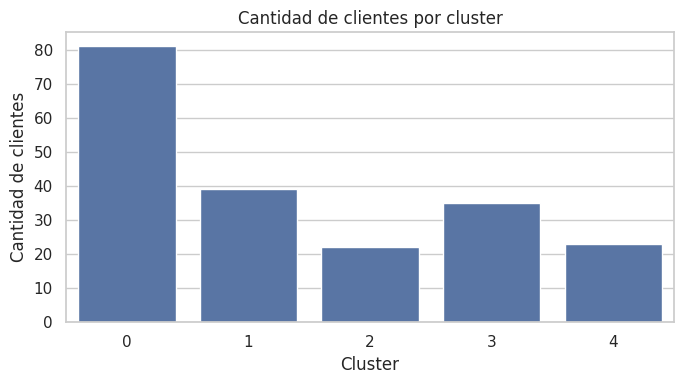

In [16]:
# ---------------------------------------------------------
# Conteo de clientes por cluster
# ---------------------------------------------------------

conteo_clusters = df_clusters["cluster"].value_counts().sort_index()

display(conteo_clusters)

# ---------------------------------------------------------
# Gráfico de barras
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.barplot(
    x=conteo_clusters.index,
    y=conteo_clusters.values
)

plt.title("Cantidad de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

## 16. Visualizamos los segmentos de clientes

Ahora vamos a graficar los clientes según las dos variables usadas para entrenar K-Means:

- `Annual Income (k$)`
- `Spending Score (1-100)`

Cada punto representa un cliente y el color indica el cluster asignado por el modelo.

También vamos a mostrar los centroides de cada cluster. Estos centroides representan el punto promedio de cada grupo en el espacio de variables. En este caso, nos ayudan a interpretar el perfil general de cada segmento.

,Annual Income (k$),Spending Score (1-100),cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


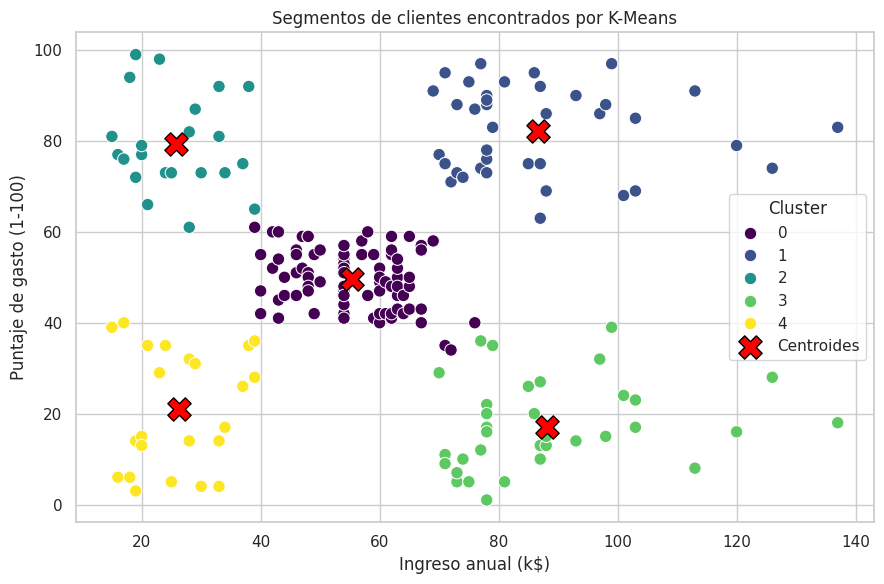

In [17]:
# ---------------------------------------------------------
# Obtenemos los centroides en escala estandarizada
# ---------------------------------------------------------

centroides_escalados = kmeans_final.cluster_centers_

# ---------------------------------------------------------
# Convertimos los centroides a la escala original
# ---------------------------------------------------------

centroides_originales = escalador.inverse_transform(centroides_escalados)

centroides_df = pd.DataFrame(
    centroides_originales,
    columns=variables_clustering
)

centroides_df["cluster"] = range(5)

display(centroides_df)

# ---------------------------------------------------------
# Gráfico de clusters y centroides
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clusters,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="cluster",
    palette="viridis",
    s=80
)

plt.scatter(
    centroides_df["Annual Income (k$)"],
    centroides_df["Spending Score (1-100)"],
    marker="X",
    s=280,
    c="red",
    edgecolor="black",
    label="Centroides"
)

plt.title("Segmentos de clientes encontrados por K-Means")
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Puntaje de gasto (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 17. Interpretamos los centroides

Los centroides nos ayudan a describir el perfil promedio de cada cluster.

En este caso, cada centroide tiene dos valores:

- ingreso anual promedio del segmento;
- puntaje de gasto promedio del segmento.

A partir de esos valores podemos empezar a interpretar los grupos encontrados por K-Means.

Por ejemplo, un cluster con ingreso anual alto y puntaje de gasto alto podría representar clientes con alto potencial comercial. En cambio, un cluster con ingreso alto pero puntaje de gasto bajo podría representar clientes con capacidad de compra, pero poco nivel de gasto dentro del centro comercial.

A continuación vamos a crear una tabla más interpretativa para describir cada segmento.

In [18]:
# ---------------------------------------------------------
# Creamos una tabla interpretativa de los segmentos
# ---------------------------------------------------------

perfiles_clusters = centroides_df.copy()

# Agregamos cantidad de clientes por cluster
perfiles_clusters["cantidad_clientes"] = perfiles_clusters["cluster"].map(conteo_clusters)

# Ordenamos las columnas para leer mejor
perfiles_clusters = perfiles_clusters[
    [
        "cluster",
        "cantidad_clientes",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

# Redondeamos valores para una lectura más clara
perfiles_clusters["Annual Income (k$)"] = perfiles_clusters["Annual Income (k$)"].round(2)
perfiles_clusters["Spending Score (1-100)"] = perfiles_clusters["Spending Score (1-100)"].round(2)

display(perfiles_clusters)

,cluster,cantidad_clientes,Annual Income (k$),Spending Score (1-100)
0,0,81,55.30,49.52
1,1,39,86.54,82.13
2,2,22,25.73,79.36
3,3,35,88.20,17.11
4,4,23,26.30,20.91


## 18. Asignamos nombres interpretativos a los clusters

Los números de cluster no tienen significado propio. Por eso, para interpretar el resultado, conviene asignarles nombres descriptivos.

A partir de los centroides, podemos proponer los siguientes perfiles:

- **Cluster 0**: ingreso medio y gasto medio.
- **Cluster 1**: ingreso alto y gasto alto.
- **Cluster 2**: ingreso bajo y gasto alto.
- **Cluster 3**: ingreso alto y gasto bajo.
- **Cluster 4**: ingreso bajo y gasto bajo.

Estos nombres no son verdades absolutas. Son interpretaciones construidas a partir de las variables usadas para el clustering.

En un análisis real, estos perfiles deberían complementarse con más información del negocio, del contexto y de los objetivos de la organización.

In [19]:
# ---------------------------------------------------------
# Diccionario con nombres interpretativos para cada cluster
# ---------------------------------------------------------

nombres_clusters = {
    0: "Ingreso medio / gasto medio",
    1: "Ingreso alto / gasto alto",
    2: "Ingreso bajo / gasto alto",
    3: "Ingreso alto / gasto bajo",
    4: "Ingreso bajo / gasto bajo"
}

# ---------------------------------------------------------
# Agregamos el nombre del perfil al dataset
# ---------------------------------------------------------

df_clusters["perfil_cliente"] = df_clusters["cluster"].map(nombres_clusters)

# ---------------------------------------------------------
# Mostramos algunas filas con la interpretación agregada
# ---------------------------------------------------------

display(df_clusters.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,perfil_cliente
0,1,Male,19,15,39,4,Ingreso bajo / gasto bajo
1,2,Male,21,15,81,2,Ingreso bajo / gasto alto
2,3,Female,20,16,6,4,Ingreso bajo / gasto bajo
3,4,Female,23,16,77,2,Ingreso bajo / gasto alto
4,5,Female,31,17,40,4,Ingreso bajo / gasto bajo


## 20. Enriquecemos la interpretación con otras variables

Hasta ahora, los clusters se formaron usando solamente dos variables:

- `Annual Income (k$)`
- `Spending Score (1-100)`

Sin embargo, el dataset contiene otras variables que pueden ayudarnos a describir mejor cada segmento.

Por ejemplo, podemos analizar:

- la edad promedio de cada grupo;
- la cantidad de clientes de cada género dentro de cada perfil.

Es importante aclarar que estas variables no fueron usadas para entrenar K-Means en este modelo. Las usaremos solamente para interpretar los clusters después de haberlos construido.

,count,mean,min,max
perfil_cliente,,,,
Ingreso bajo / gasto alto,22,25.27,18,35
Ingreso alto / gasto alto,39,32.69,27,40
Ingreso alto / gasto bajo,35,41.11,19,59
Ingreso medio / gasto medio,81,42.72,18,70
Ingreso bajo / gasto bajo,23,45.22,19,67


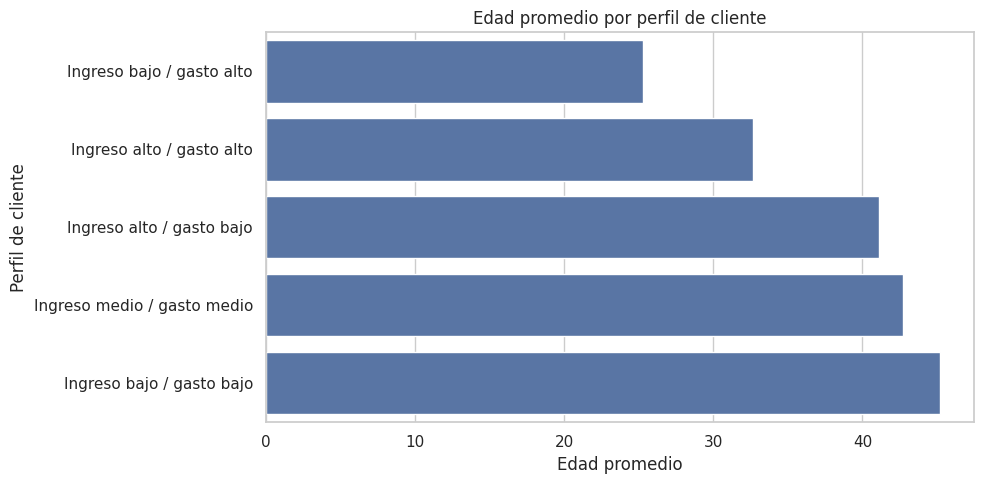

In [20]:
# ---------------------------------------------------------
# Resumen de edad por perfil de cliente
# ---------------------------------------------------------

resumen_edad = df_clusters.groupby("perfil_cliente")["Age"].agg(
    ["count", "mean", "min", "max"]
).sort_values(by="mean")

# Redondeamos la edad promedio para facilitar la lectura
resumen_edad["mean"] = resumen_edad["mean"].round(2)

display(resumen_edad)

# ---------------------------------------------------------
# Gráfico de edad promedio por perfil
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_edad.reset_index(),
    x="mean",
    y="perfil_cliente"
)

plt.title("Edad promedio por perfil de cliente")
plt.xlabel("Edad promedio")
plt.ylabel("Perfil de cliente")
plt.tight_layout()
plt.show()

## 21. Analizamos la distribución por género

También podemos observar cómo se distribuye la variable `Gender` dentro de cada perfil.

Esto no significa que el género haya sido usado por el algoritmo para formar los clusters. En este caso, K-Means solo usó ingreso anual y puntaje de gasto.

La tabla y el gráfico siguientes nos ayudan a describir los segmentos encontrados, pero no explican por sí solos cómo fueron construidos.

Gender,Female,Male
perfil_cliente,,
Ingreso alto / gasto alto,21,18
Ingreso alto / gasto bajo,16,19
Ingreso bajo / gasto alto,13,9
Ingreso bajo / gasto bajo,14,9
Ingreso medio / gasto medio,48,33


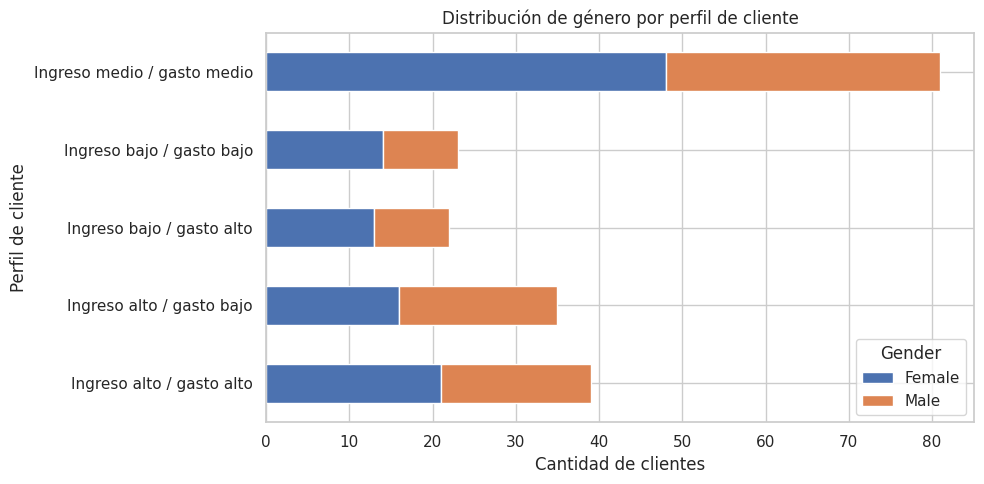

In [21]:
# ---------------------------------------------------------
# Tabla cruzada entre perfil de cliente y género
# ---------------------------------------------------------

tabla_genero = pd.crosstab(
    df_clusters["perfil_cliente"],
    df_clusters["Gender"]
)

display(tabla_genero)

# ---------------------------------------------------------
# Gráfico de barras apiladas
# ---------------------------------------------------------

tabla_genero.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Distribución de género por perfil de cliente")
plt.xlabel("Cantidad de clientes")
plt.ylabel("Perfil de cliente")
plt.tight_layout()
plt.show()

## 22. Interpretamos los perfiles enriquecidos

El análisis de edad y género permite describir mejor los segmentos encontrados por K-Means.

En relación con la edad, se observa que los perfiles con mayor puntaje de gasto tienden a ser más jóvenes:

- el perfil **Ingreso bajo / gasto alto** tiene una edad promedio cercana a los 25 años;
- el perfil **Ingreso alto / gasto alto** tiene una edad promedio cercana a los 33 años.

En cambio, los perfiles con gasto medio o bajo presentan edades promedio más altas.

Esto no significa que la edad haya sido usada por el algoritmo para formar los clusters. Recordemos que K-Means solo trabajó con ingreso anual y puntaje de gasto. La edad se utiliza aquí como una variable adicional para interpretar mejor los grupos encontrados.

La distribución por género muestra que todos los perfiles incluyen clientes de ambos géneros. No parece haber una separación absoluta por esta variable, aunque sí pueden observarse algunas diferencias en la cantidad de registros dentro de cada segmento.

Este paso es importante porque muestra una práctica habitual en clustering:

> primero formamos los clusters con ciertas variables, y luego usamos otras variables disponibles para describir e interpretar mejor cada grupo.

De esta manera, el clustering deja de ser solamente una técnica matemática y se convierte en una herramienta para construir perfiles útiles.

## 23. Posibles acciones según cada perfil

Una vez interpretados los clusters, podemos pensar qué utilidad práctica podrían tener.

Por ejemplo, los perfiles encontrados podrían orientar distintas estrategias comerciales:

- **Ingreso alto / gasto alto**: clientes de alto valor. Podrían recibir beneficios exclusivos, programas de fidelización o propuestas premium.
- **Ingreso alto / gasto bajo**: clientes con capacidad de compra, pero bajo nivel de gasto registrado. Podrían recibir campañas personalizadas para incentivar su participación.
- **Ingreso bajo / gasto alto**: clientes muy activos en consumo, aunque con menor ingreso estimado. Podrían responder bien a promociones, descuentos o beneficios por frecuencia.
- **Ingreso bajo / gasto bajo**: clientes de menor actividad comercial. Podrían requerir estrategias de atracción o promociones iniciales.
- **Ingreso medio / gasto medio**: grupo central y numeroso. Podría representar una base estable de clientes, útil para campañas generales.

Estas interpretaciones son hipótesis. En un caso real, deberían validarse con más información del negocio, comportamiento histórico, objetivos comerciales y análisis complementarios.

## 24. Limitaciones del análisis

Aunque el clustering obtenido es claro e interpretable, es importante reconocer sus limitaciones.

En este cuaderno usamos solamente dos variables para entrenar K-Means:

- ingreso anual;
- puntaje de gasto.

Esto permitió construir una visualización clara, pero también simplificó mucho el problema. En una situación real, el comportamiento de los clientes podría depender de muchas otras variables: frecuencia de compra, categorías de productos, visitas al local, uso de promociones, ubicación, historial temporal, entre otras.

Además, los nombres asignados a los perfiles son interpretaciones construidas a partir de los centroides. No son etiquetas reales ni verdades absolutas.

También debemos recordar que K-Means fuerza a cada cliente a pertenecer a un único cluster. En la práctica, algunos clientes pueden estar cerca de la frontera entre segmentos y podrían compartir características de más de un perfil.

Por eso, los resultados de un clustering deben usarse como punto de partida para explorar y tomar decisiones, no como una clasificación definitiva e incuestionable.

# Reflexión final

En este cuaderno aplicamos K-Means a un caso realista de segmentación de clientes.

A diferencia del primer cuaderno, donde trabajamos con datos sintéticos, aquí usamos un dataset real con información de clientes de un centro comercial. Y a diferencia del segundo cuaderno, donde K-Means funcionaba solo parcialmente sobre Palmer Penguins, en este caso los clusters encontrados resultaron más fáciles de interpretar desde una perspectiva práctica.

El objetivo fue agrupar clientes según dos variables:

- `Annual Income (k$)`;
- `Spending Score (1-100)`.

A partir del análisis con inercia y silhouette score, elegimos trabajar con `k = 5`. Luego entrenamos el modelo final, visualizamos los clusters, analizamos los centroides y asignamos nombres interpretativos a cada segmento.

Los perfiles encontrados fueron:

- ingreso medio / gasto medio;
- ingreso alto / gasto alto;
- ingreso bajo / gasto alto;
- ingreso alto / gasto bajo;
- ingreso bajo / gasto bajo.

Este recorrido muestra una aplicación típica del aprendizaje no supervisado: no partimos de etiquetas conocidas, sino que buscamos patrones en los datos y luego intentamos darles sentido.

La idea central es que el clustering no termina cuando el algoritmo asigna un número de cluster. El paso más importante es interpretar esos grupos, revisar si tienen sentido, enriquecerlos con otras variables y pensar qué decisiones podrían tomarse a partir de ellos.

En este caso, K-Means permitió transformar una tabla de clientes en una segmentación más comprensible y accionable.